# 📊 Student Performance Prediction
## Notebook 2 — Model Training, Comparison & Selection

**Algorithms Compared:**
- Linear Regression (baseline)
- Ridge Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost / Extra Trees
- Support Vector Regression

**Metrics:** R², RMSE, MAE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('student_cleaned.csv')
print(f'Data shape: {df.shape}')
df.head(3)

Data shape: (1000, 14)


,age,gender,study_hours_per_day,social_media_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,0,0.0,1.2,0,85.0,8.0,1,6,2,1,8,1,56.2
1,20,0,6.9,2.8,0,97.3,4.6,2,6,0,1,8,0,100.0
2,21,1,1.4,3.1,0,94.8,8.0,0,1,0,0,1,0,34.3


## 1. Feature Engineering & Train/Test Split

In [2]:
X = df.drop(columns=['exam_score'])
y = df['exam_score']

FEATURES = list(X.columns)
print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Target: exam_score | Range: {y.min():.1f} - {y.max():.1f}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'\nTrain: {X_train.shape} | Test: {X_test.shape}')

# Scale features (critical for SVR, Ridge)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Save scaler for Streamlit app
joblib.dump(scaler, 'models/scaler.pkl')
print('✅ Scaler saved')

Features (13): ['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']
Target: exam_score | Range: 18.4 - 100.0

Train: (800, 13) | Test: (200, 13)
✅ Scaler saved


## 2. Define & Train All Models

In [3]:
models = {
    'Linear Regression':        LinearRegression(),
    'Ridge Regression':         Ridge(alpha=1.0),
    'Lasso Regression':         Lasso(alpha=0.1),
    'Random Forest':            RandomForestRegressor(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1),
    'Gradient Boosting':        GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    'Extra Trees':              ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'SVR':                      SVR(kernel='rbf', C=100, epsilon=0.1),
}

results = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Use scaled data for SVR, Ridge, Lasso; raw for tree models
    use_scaled = name in ['Ridge Regression', 'Lasso Regression', 'SVR', 'Linear Regression']
    Xtr = X_train_sc if use_scaled else X_train
    Xte = X_test_sc  if use_scaled else X_test
    
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    
    # Cross-validation R²
    cv_r2 = cross_val_score(model, Xtr if use_scaled else X_train, y_train,
                            cv=kf, scoring='r2').mean()
    
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    
    results.append({'Model': name, 'R²': round(r2, 4),
                    'CV R²': round(cv_r2, 4),
                    'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
                    'scaled': use_scaled})
    print(f'{name:<25} | R²={r2:.4f} | CV R²={cv_r2:.4f} | RMSE={rmse:.4f} | MAE={mae:.4f}')

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print('\n📊 Results sorted by R²:')
results_df[['Model','R²','CV R²','RMSE','MAE']]

Linear Regression         | R²=0.8807 | CV R²=0.8742 | RMSE=5.5317 | MAE=4.4561
Ridge Regression          | R²=0.8806 | CV R²=0.8742 | RMSE=5.5332 | MAE=4.4573
Lasso Regression          | R²=0.8810 | CV R²=0.8750 | RMSE=5.5245 | MAE=4.4587
Random Forest             | R²=0.8439 | CV R²=0.8330 | RMSE=6.3263 | MAE=4.9593
Gradient Boosting         | R²=0.8574 | CV R²=0.8416 | RMSE=6.0469 | MAE=4.8198
Extra Trees               | R²=0.8480 | CV R²=0.8313 | RMSE=6.2433 | MAE=4.9770
SVR                       | R²=0.7835 | CV R²=0.7774 | RMSE=7.4503 | MAE=5.6800

📊 Results sorted by R²:


,Model,R²,CV R²,RMSE,MAE
2,Lasso Regression,0.8810,0.8750,5.5245,4.4587
0,Linear Regression,0.8807,0.8742,5.5317,4.4561
1,Ridge Regression,0.8806,0.8742,5.5332,4.4573
4,Gradient Boosting,0.8574,0.8416,6.0469,4.8198
5,Extra Trees,0.8480,0.8313,6.2433,4.9770
3,Random Forest,0.8439,0.8330,6.3263,4.9593
6,SVR,0.7835,0.7774,7.4503,5.6800


## 3. Model Comparison Plot

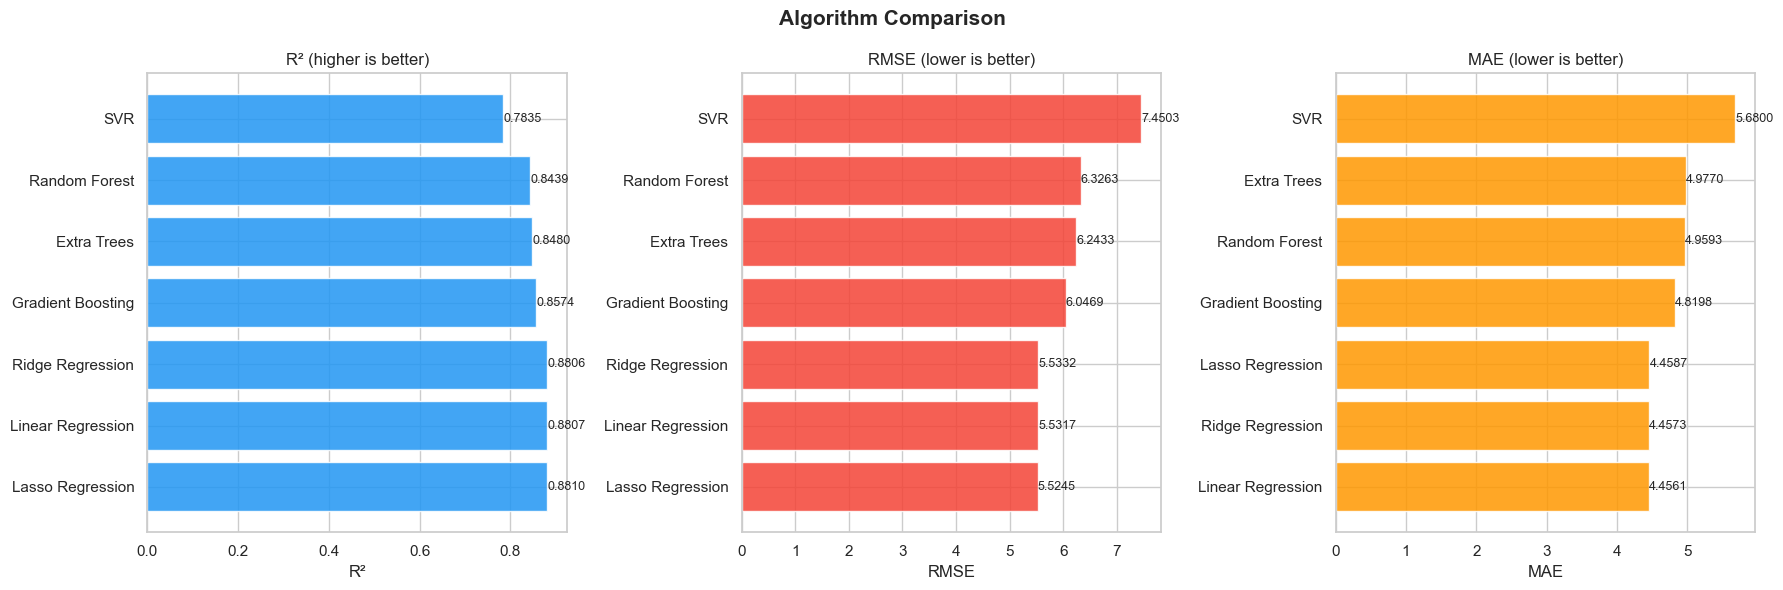

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['R²', 'RMSE', 'MAE']
colors  = ['#2196F3', '#F44336', '#FF9800']
better  = ['higher', 'lower', 'lower']

for ax, metric, color, direction in zip(axes, metrics, colors, better):
    ordered = results_df.sort_values(metric, ascending=(direction == 'lower'))
    bars = ax.barh(ordered['Model'], ordered[metric], color=color, alpha=0.85)
    ax.set_title(f'{metric} ({direction} is better)', fontsize=12)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, ordered[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Algorithm Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Best Model — Deep Evaluation

🏆 Best Model: Lasso Regression
   R² = 0.881 | RMSE = 5.5245 | MAE = 4.4587


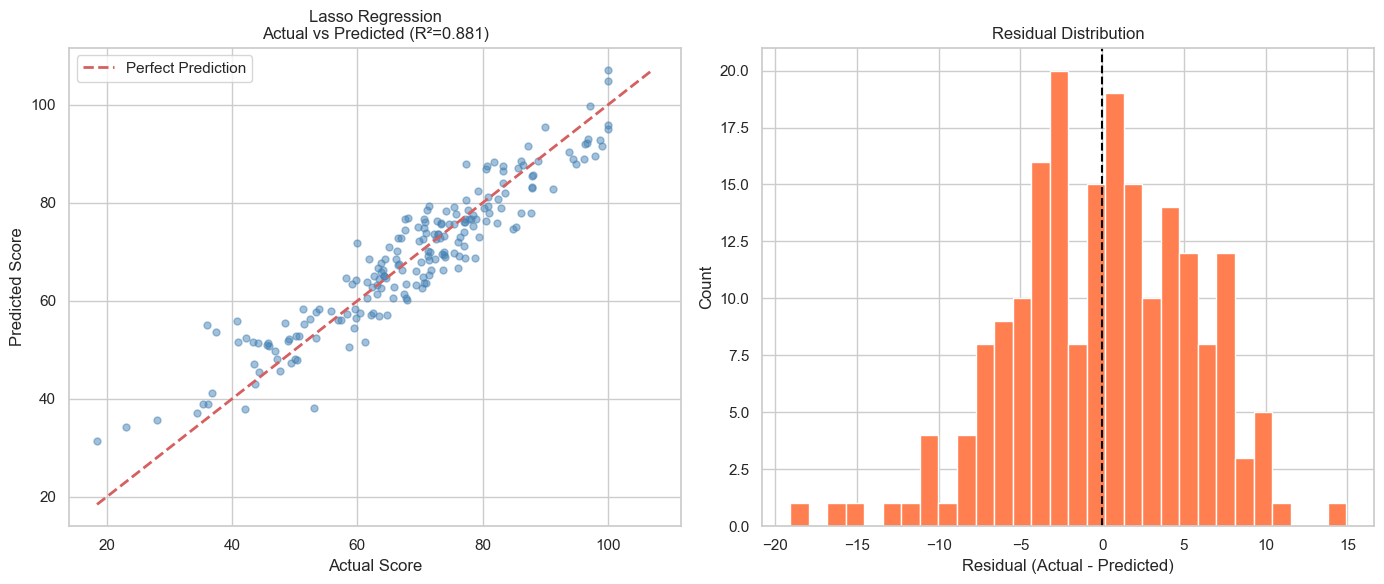

In [5]:
best_name = results_df.iloc[0]['Model']
use_sc    = results_df.iloc[0]['scaled']
best_model = models[best_name]
print(f'🏆 Best Model: {best_name}')
print(f'   R² = {results_df.iloc[0]["R²"]} | RMSE = {results_df.iloc[0]["RMSE"]} | MAE = {results_df.iloc[0]["MAE"]}')

Xte = X_test_sc if use_sc else X_test
y_pred_best = best_model.predict(Xte)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.5, s=25, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Score')
axes[0].set_ylabel('Predicted Score')
axes[0].set_title(f'{best_name}\nActual vs Predicted (R²={results_df.iloc[0]["R²"]})')
axes[0].legend()

# Residuals
residuals = y_test.values - y_pred_best
axes[1].hist(residuals, bins=30, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.tight_layout()
plt.savefig('plots/06_best_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Feature Importance

Lasso Regression does not expose feature importances. Using permutation importance...


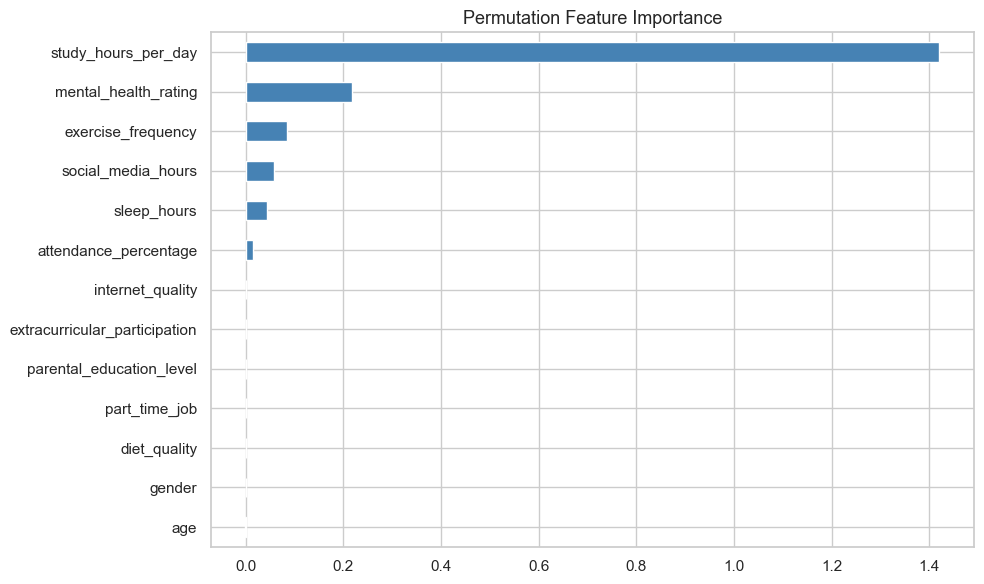

In [6]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    colors_imp = ['#c0392b' if v == importances.max() else '#3498db' for v in importances]
    importances.plot(kind='barh', color=colors_imp)
    plt.title(f'Feature Importance — {best_name}', fontsize=13)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('plots/07_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Top 5 features:')
    print(importances.sort_values(ascending=False).head(5))
else:
    print(f'{best_name} does not expose feature importances. Using permutation importance...')
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(best_model, Xte, y_test, n_repeats=10, random_state=42)
    imp_df = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=True)
    imp_df.plot(kind='barh', color='steelblue', figsize=(10, 6))
    plt.title('Permutation Feature Importance', fontsize=13)
    plt.tight_layout()
    plt.savefig('plots/07_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Save Best Model & Metadata

In [7]:
import json

joblib.dump(best_model, 'models/best_model.pkl')

metadata = {
    'model_name': best_name,
    'features': FEATURES,
    'r2': float(results_df.iloc[0]['R²']),
    'rmse': float(results_df.iloc[0]['RMSE']),
    'mae': float(results_df.iloc[0]['MAE']),
    'cv_r2': float(results_df.iloc[0]['CV R²']),
    'use_scaler': bool(use_sc),
    'all_results': results_df[['Model','R²','CV R²','RMSE','MAE']].to_dict(orient='records')
}

with open('models/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'✅ Model saved: models/best_model.pkl')
print(f'✅ Metadata saved: models/metadata.json')
print(f'\n🏆 Best: {best_name}')
print(f'   R² = {metadata["r2"]} | RMSE = {metadata["rmse"]} | MAE = {metadata["mae"]}')

✅ Model saved: models/best_model.pkl
✅ Metadata saved: models/metadata.json

🏆 Best: Lasso Regression
   R² = 0.881 | RMSE = 5.5245 | MAE = 4.4587
